In [264]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D
import seaborn as sns
from scipy.stats import chi2 as chi2_dist
from scipy.stats import chi2_contingency
import prince
import jenkspy


In [265]:
# Make sure to upload your kaggle.json file to your working directory
# On a local machine, place it in the ~/.kaggle/ directory.

# Download the dataset
!kaggle datasets download -d abdullahmeo/housing-price-prediction -f Housing.csv --force

# Read the data from the extracted directory
df = pd.read_csv("Housing.csv")

# Taking a look in the first rows
print('First rows:')
print(df.head())

Dataset URL: https://www.kaggle.com/datasets/abdullahmeo/housing-price-prediction
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)

First rows:



  0%|          | 0.00/29.3k [00:00<?, ?B/s]
100%|██████████| 29.3k/29.3k [00:00<00:00, 7.35MB/s]


      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [266]:
# Understanding the data structure
print('\nData Info:')
print(df.info())


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


>No missing values in the dataset.


In [267]:
# Looking the statistical summary
print('\nStatistical Summary:')
print(df.describe())


Statistical Summary:
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


In [268]:
# Binning continuous variables using Jenks Natural Breaks

breaks_price = jenkspy.jenks_breaks(df['price'], n_classes=4)
breaks_area = jenkspy.jenks_breaks(df['area'], n_classes=4)

df['price_bin'] = pd.cut(df['price'], bins=breaks_price, include_lowest=True, labels=['low', 'medium', 'high', 'very_high'])
df['area_bin'] = pd.cut(df['area'], bins=breaks_area, include_lowest=True, labels=['small', 'medium', 'large', 'very_large'])



print("Distribuição de price_bin (Jenks):")
print(df['price_bin'].value_counts().sort_index())
print("\nLimites de price_bin:")
print(df.groupby('price_bin')['price'].agg(['min', 'max', 'count']))

Distribuição de price_bin (Jenks):
price_bin
low          196
medium       185
high         122
very_high     42
Name: count, dtype: int64

Limites de price_bin:
               min       max  count
price_bin                          
low        1750000   3780000    196
medium     3815000   5390000    185
high       5425000   7700000    122
very_high  7840000  13300000     42


C:\Users\yuhmo\AppData\Local\Temp\ipykernel_127672\1112280091.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('price_bin')['price'].agg(['min', 'max', 'count']))


>Why Jenks Natural Breaks is a Good Choice for Binning
>
>Jenks Natural Breaks is a data-driven clustering algorithm that identifies the "natural" gaps in your distribution by minimizing variance within groups and maximizing it between them. Unlike Equal-Width binning, which ignores data density and creates sparse bins, or Equal-Frequency, which arbitrarily splits natural clusters to force equal counts, Jenks respects the inherent structure of your data. It provides an objective, reproducible way to categorize continuous variables (like price and area) without the researcher bias found in manual binning.

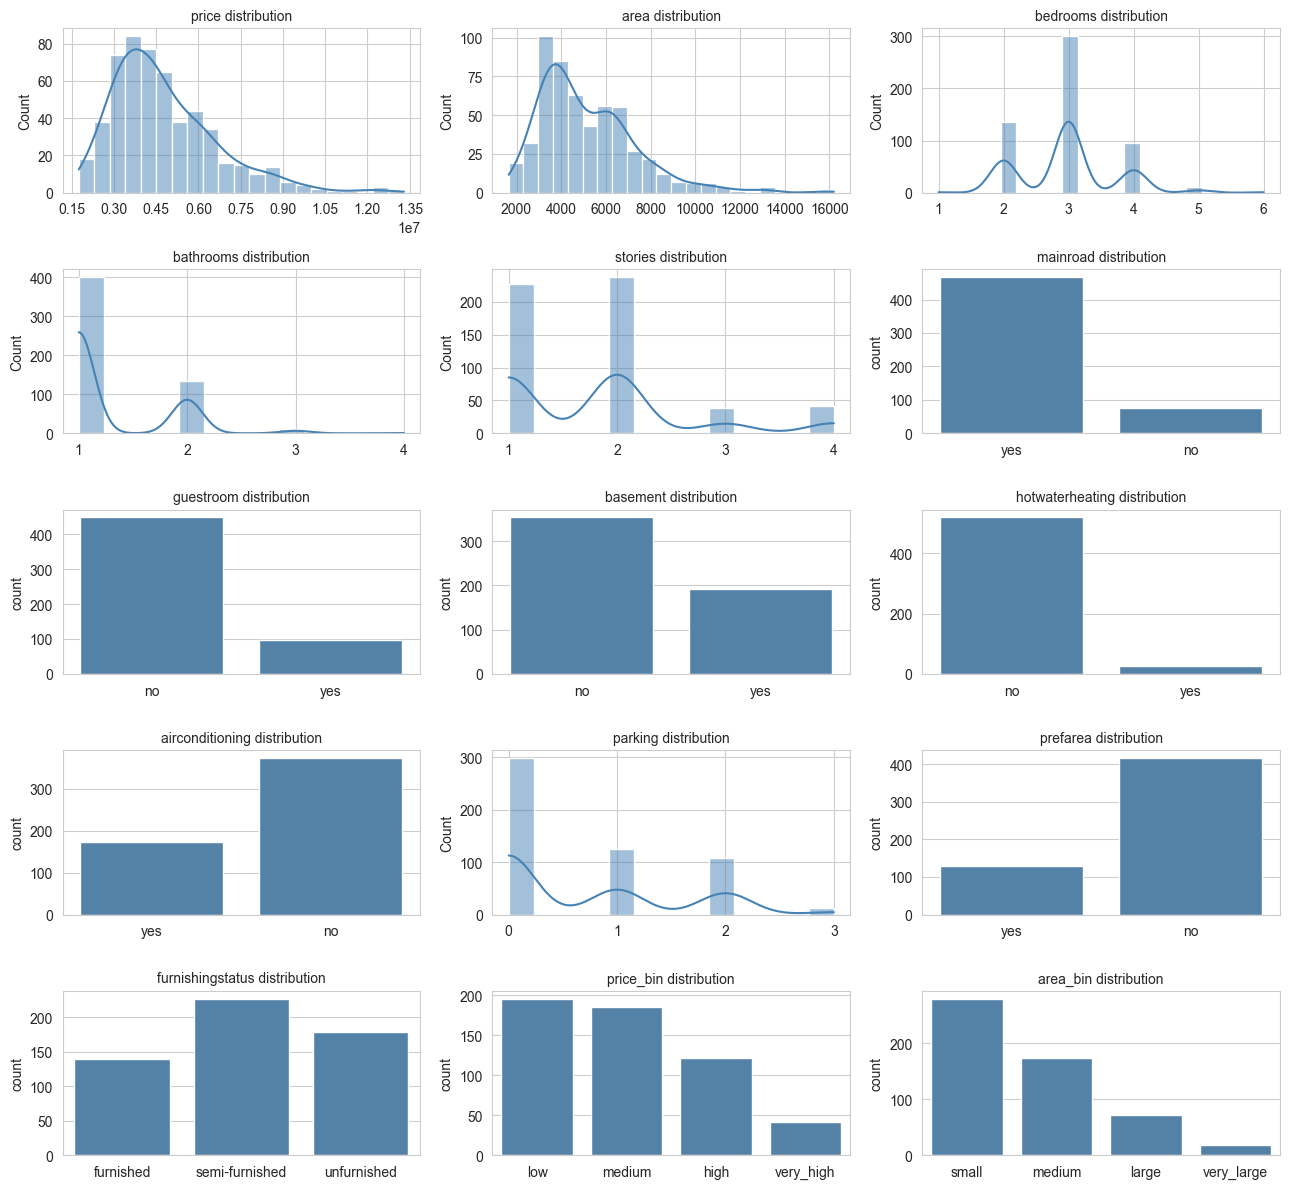

In [269]:
# Taking a look at the distribution of each feature

# List of features to plot
features = df.columns

# Configuring the plots
fig, axes = plt.subplots(5, 3, figsize=(13, 12))
axes = axes.flatten()  # Transform the matrix of axes into a flat array

# Loop to create histograms
for i, col in enumerate(features):
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        sns.countplot(data=df, x=col, ax=axes[i], color='steelblue')
    else:
        sns.histplot(df[col], ax=axes[i], kde=True, color='steelblue')
        axes[i].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    
    axes[i].set_title(f'{col} distribution', fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

>Features such as bedrooms, bathrooms, and hotwaterheating contain potential outliers. While these could distort the analysis, they may also be intrinsically linked to higher-priced houses, representing legitimate high-end market segments; therefore, they will not be excluded from the analysis.


Chi-squared Test:
Chi2 Statistic: 183.5960, p-value: 8.98651e-35, dof: 9


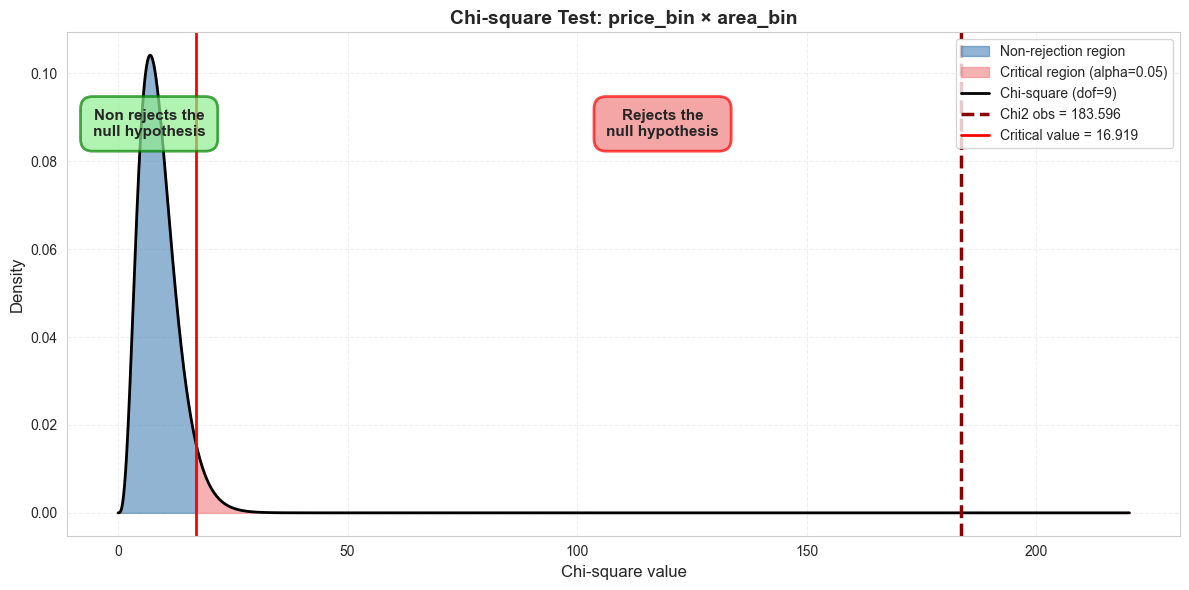


Decision at alpha=0.05: Rejects the null hypothesis


In [270]:
# Chi-squared test between 'price_bin' and 'area_bin'

feature1 = df['price_bin']
feature2 = df['area_bin']

contingency_table = pd.crosstab(feature1, feature2)
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f'\nChi-squared Test:\nChi2 Statistic: {chi2_stat:.4f}, p-value: {p_value:.6g}, dof: {dof}')

# Distribution plot with critical regions
alpha = 0.05  # Significance level
critical_value = chi2_dist.ppf(1 - alpha, dof)

x_max = max(chi2_dist.ppf(0.999, dof), chi2_stat * 1.2, critical_value * 1.2)
x = np.linspace(0, x_max, 2000)
y = chi2_dist.pdf(x, dof)

plt.figure(figsize=(12, 6))

# Non rejection area
x_non_reject = x[x <= critical_value]
plt.fill_between(x_non_reject, chi2_dist.pdf(x_non_reject, dof),
                 color="steelblue", alpha=0.6, label="Non-rejection region")

# Critical region
x_critical = x[x >= critical_value]
plt.fill_between(x_critical, chi2_dist.pdf(x_critical, dof),
                 color="lightcoral", alpha=0.6, label=f"Critical region (alpha={alpha})")

# Distribution curve
plt.plot(x, y, color="black", lw=2, label=f"Chi-square (dof={dof})")

# Statistic observed line
plt.axvline(chi2_stat, color="darkred", lw=2.5, linestyle="--",
            label=f"Chi2 obs = {chi2_stat:.3f}")

# LCritical value line
plt.axvline(critical_value, color="red", lw=2, linestyle="-",
            label=f"Critical value = {critical_value:.3f}")

# Text box with decision
decision = "Rejects the null hypothesis" if p_value < alpha else "Non rejects the null hypothesis"
decision_color = "lightcoral" if p_value < alpha else "lightgreen"

# Rejection box
plt.text(critical_value + (x_max - critical_value)*0.5, max(y)*0.85,
         "Rejects the\nnull hypothesis",
         fontsize=11, weight='bold', ha='center', va='center',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='lightcoral', 
                   edgecolor='red', alpha=0.7, linewidth=2))

# CNon rejection box
plt.text(critical_value * 0.4, max(y)*0.85,
         "Non rejects the\nnull hypothesis",
         fontsize=11, weight='bold', ha='center', va='center',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='lightgreen', 
                   edgecolor='green', alpha=0.7, linewidth=2))

plt.title(f"Chi-square Test: {feature1.name} × {feature2.name}", fontsize=14, weight='bold')
plt.xlabel("Chi-square value", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Final decision output
print(f"\nDecision at alpha={alpha}: {decision}")

>The Chi-Square test is the essential first step for CA/MCA because it statistically validates whether a real association exists between your categorical variables before you attempt to map them. 

>Since Correspondence Analysis is essentially a visual decomposition of the Chi-Square statistic, the test ensures that the patterns you see in the perceptual map are based on significant dependencies rather than random noise. By confirming that the p-value is below your significance threshold, you gain the mathematical justification needed to interpret the distances and clusters in your final visualization as reliable business insights.

In [271]:
# Create a comprehensive chi-square test function for all categorical features

def chi_square_test_all_features(df, target_feature, alpha=0.05, exclude_features=None):
    """
    Performs chi-square test between a target feature and all categorical features in the dataframe.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The input dataframe
    target_feature : str
        The name of the target feature to test against
    alpha : float, default=0.05
        Significance level for the test
    exclude_features : list, default=None
        List of feature names to exclude from testing (e.g., continuous variables, IDs)
    
    Returns:
    --------
    results_df : pandas.DataFrame
        DataFrame with test results sorted by p-value
    """
    
    if target_feature not in df.columns:
        raise ValueError(f"Target feature '{target_feature}' not found in dataframe")
    
    # Initialize lists to store results
    results = []
    
    # Get all columns except the target
    features_to_test = [col for col in df.columns if col != target_feature]
    
    # Exclude specified features
    if exclude_features:
        features_to_test = [col for col in features_to_test if col not in exclude_features]
    
    # Identify categorical features (object, category, or low cardinality numeric)
    categorical_features = []
    for col in features_to_test:
        # Check if column is categorical type or object
        if df[col].dtype in ['object', 'category']:
            categorical_features.append(col)
        # Check if numeric but with low unique values (likely categorical)
        elif df[col].dtype in ['int64', 'float64']:
            n_unique = df[col].nunique()
            # Consider as categorical if less than 10 unique values or less than 5% of total rows
            if n_unique < 10 or n_unique < len(df) * 0.05:
                categorical_features.append(col)
    
    print(f"Testing {len(categorical_features)} categorical features against '{target_feature}'")
    print(f"Significance level (α): {alpha}")
    print("="*80)
    
    # Perform chi-square test for each categorical feature
    for feature in categorical_features:
        try:
            # Create contingency table
            contingency_table = pd.crosstab(df[feature], df[target_feature])
            
            # Perform chi-square test
            chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_table)
            
            # Check if any expected frequency is less than 5 (validity warning)
            min_expected = expected_freq.min()
            validity_warning = "⚠️ Low expected freq" if min_expected < 5 else "✓"
            
            # Determine if significant
            is_significant = p_value < alpha
            
            # Calculate Cramér's V (effect size)
            n = contingency_table.sum().sum()
            min_dim = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)
            cramers_v = np.sqrt(chi2_stat / (n * min_dim)) if min_dim > 0 else 0
            
            # Interpret effect size
            if cramers_v < 0.1:
                effect_size = "Negligible"
            elif cramers_v < 0.3:
                effect_size = "Small"
            elif cramers_v < 0.5:
                effect_size = "Medium"
            else:
                effect_size = "Large"
            
            results.append({
                'Feature': feature,
                'Chi² Statistic': chi2_stat,
                'p-value': p_value,
                'DoF': dof,
                'Significant (α=0.05)': '✓ Yes' if is_significant else '✗ No',
                "Cramér's V": cramers_v,
                'Effect Size': effect_size,
                'Min Expected Freq': min_expected,
                'Validity': validity_warning,
                'Table Shape': f"{contingency_table.shape[0]}×{contingency_table.shape[1]}"
            })
            
        except Exception as e:
            results.append({
                'Feature': feature,
                'Chi² Statistic': np.nan,
                'p-value': np.nan,
                'DoF': np.nan,
                'Significant (α=0.05)': f'Error: {str(e)[:30]}',
                "Cramér's V": np.nan,
                'Effect Size': 'N/A',
                'Min Expected Freq': np.nan,
                'Validity': '✗',
                'Table Shape': 'N/A'
            })
    
    # Create results dataframe
    results_df = pd.DataFrame(results)
    
    # Sort by p-value (ascending)
    results_df = results_df.sort_values('p-value', ascending=True).reset_index(drop=True)
    
    # Split into significant and non-significant
    significant_df = results_df[results_df['Significant (α=0.05)'] == '✓ Yes'].copy()
    non_significant_df = results_df[results_df['Significant (α=0.05)'] == '✗ No'].copy()
    
    # Display significant results  
    print("\n" + "="*80)
    print("SUMMARY")
    print("="*80)
    print(f"Total features tested: {len(categorical_features)}")
    print(f"Significant: {len(significant_df)} ({len(significant_df)/len(categorical_features)*100:.1f}%)")
    print(f"Non-significant: {len(non_significant_df)} ({len(non_significant_df)/len(categorical_features)*100:.1f}%)")
    print("="*80)
    
    print("\n📊 INTERPRETATION GUIDE:")
    print("• Cramér's V: 0-0.1 (Negligible), 0.1-0.3 (Small), 0.3-0.5 (Medium), >0.5 (Large)")
    print("• ⚠️ Low expected freq: Chi-square may not be valid (consider Fisher's exact test)")
    print("• Effect size matters: A significant p-value doesn't always mean practical importance")
    
    return results_df

# Example code to demonstrate usage (commented out):
"""
# Example usage:
results = chi_square_test_all_features(
    df=df, 
    target_feature='price_bin',
    alpha=0.05,
    exclude_features=['price', 'area']  # Exclude continuous variables
)

# Access the results dataframe
print(results.head())
"""

print("✓ Function 'chi_square_test_all_features' created successfully!")
print("\nUsage example:")
print("results = chi_square_test_all_features(df, target_feature='price_bin', exclude_features=['price', 'area'])")

# Test all categorical features against 'price_bin'
results = chi_square_test_all_features(
    df=df,
    target_feature='price_bin',
    alpha=0.05,
    exclude_features=['price', 'area']  # Exclude continuous variables
)

# The function prints formatted tables automatically
# You can also access the results dataframe for further analysis
print(results)

✓ Function 'chi_square_test_all_features' created successfully!

Usage example:
results = chi_square_test_all_features(df, target_feature='price_bin', exclude_features=['price', 'area'])
Testing 12 categorical features against 'price_bin'
Significance level (α): 0.05

SUMMARY
Total features tested: 12
Significant: 11 (91.7%)
Non-significant: 1 (8.3%)

📊 INTERPRETATION GUIDE:
• Cramér's V: 0-0.1 (Negligible), 0.1-0.3 (Small), 0.3-0.5 (Medium), >0.5 (Large)
• ⚠️ Low expected freq: Chi-square may not be valid (consider Fisher's exact test)
• Effect size matters: A significant p-value doesn't always mean practical importance
             Feature  Chi² Statistic       p-value  DoF Significant (α=0.05)  \
0           area_bin      183.596039  8.986507e-35    9                ✓ Yes   
1          bathrooms      158.648804  1.417327e-29    9                ✓ Yes   
2            stories      153.561935  1.611313e-28    9                ✓ Yes   
3    airconditioning      109.199853  1.631278e-23 

>While the p-value confirms if an association is statistically significant, Cramér's V measures the actual strength of that relationship, helping you prioritize features with practical importance. 
>
>Using both ensures you select variables that are not only reliable but also have enough discriminatory power to create a meaningful and clear perceptual map in CA/MCA.

In [272]:
# Contingency table
contingency_table = pd.crosstab(feature1, feature2)
print("Contingency table:")
print(contingency_table)
print("\n" + "="*70 + "\n")

# Chi-squared test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f'Chi-squared Test:')
print(f'Chi2 Statistic: {chi2_stat:.4f}')
print(f'p-value: {p_value:.6f}')
print(f'dof: {dof}')
print("\n" + "="*70 + "\n")

# Adjusted Standardized Residuals Calculation
observed = contingency_table.values
n = observed.sum()

# Marginal totals
row_totals = observed.sum(axis=1)
col_totals = observed.sum(axis=0)

# Adjusted Standardized Residuals
adjusted_residuals = np.zeros_like(observed, dtype=float)

for i in range(observed.shape[0]):
    for j in range(observed.shape[1]):
        # Expected frequency
        E_ij = expected[i, j]
        
        # Observed frequency
        O_ij = observed[i, j]
        
        # Residuals
        residual = O_ij - E_ij
        
        # Adjusted standardized residual
        p_i = row_totals[i] / n
        p_j = col_totals[j] / n
        
        denominator = np.sqrt(E_ij * (1 - p_i) * (1 - p_j))
        
        if denominator > 0:
            adjusted_residuals[i, j] = residual / denominator
        else:
            adjusted_residuals[i, j] = 0

# DataFrame for better visualization
residuals_df = pd.DataFrame(
    adjusted_residuals,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print("Adjusted Standardized Residuals:")
print(residuals_df.round(3))
print("\n" + "="*70 + "\n")

# Finding significant cells | resíduo| > 1.96 (significativo a 5%)
threshold = 1.96
significant_cells = []

for i in range(adjusted_residuals.shape[0]):
    for j in range(adjusted_residuals.shape[1]):
        residual_value = adjusted_residuals[i, j]
        if abs(residual_value) > threshold:
            row_label = contingency_table.index[i]
            col_label = contingency_table.columns[j]
            observed_freq = observed[i, j]
            expected_freq = expected[i, j]
            
            # Interpretation
            if residual_value > 0:
                interpretation = "POSITIVE Association (more than expected)"
            else:
                interpretation = "NEGATIVE Association (less than expected)"
            
            significant_cells.append({
                f'{feature1.name}': row_label,
                f'{feature2.name}': col_label,
                'Observed': observed_freq,
                'Expected': round(expected_freq, 2),
                'Adjusted Residual': round(residual_value, 3),
                'Interpretation': interpretation
            })

# Dataframe of significant cells
if significant_cells:
    significant_df = pd.DataFrame(significant_cells)
    print(f"Significant cells with |Adjusted Residual| > {threshold} (significant at 5%):")
    print(significant_df.to_string(index=False))
    print(f"\n✓ Total of {len(significant_cells)} significant cell(s) found")
else:
    print(f"✗ No cells with |Adjusted Residual| > {threshold} were found.")
    print("It means there is no significant association between the categories.")

print("\n" + "="*70 + "\n")
print("Adjusted Standardized Residuals Interpretation:")
print("• |z| > 1.96: Significant at 5% (p < 0.05)")
print("• |z| > 2.58: Significant at 1% (p < 0.01)")
print("• |z| > 3.29: Significant at 0.1% (p < 0.001)")
print("• z > 0: More observations than expected (positive association)")
print("• z < 0: Fewer observations than expected (negative association)")

Contingency table:
area_bin   small  medium  large  very_large
price_bin                                  
low          156      30      9           1
medium       102      54     23           6
high          18      74     21           9
very_high      4      16     19           3


Chi-squared Test:
Chi2 Statistic: 183.5960
p-value: 0.000000
dof: 9


Adjusted Standardized Residuals:
area_bin   small  medium  large  very_large
price_bin                                  
low        9.876  -6.237 -4.453      -2.838
medium     1.259  -0.983 -0.385      -0.222
high      -9.186   7.726  1.482       2.659
very_high -5.649   0.893  6.381       1.345


Significant cells with |Adjusted Residual| > 1.96 (significant at 5%):
price_bin   area_bin  Observed  Expected  Adjusted Residual                            Interpretation
      low      small       156    100.70              9.876 POSITIVE Association (more than expected)
      low     medium        30     62.58             -6.237 NEGATIVE As

Contingency Table:
area_bin   small  medium  large  very_large
price_bin                                  
low          156      30      9           1
medium       102      54     23           6
high          18      74     21           9
very_high      4      16     19           3




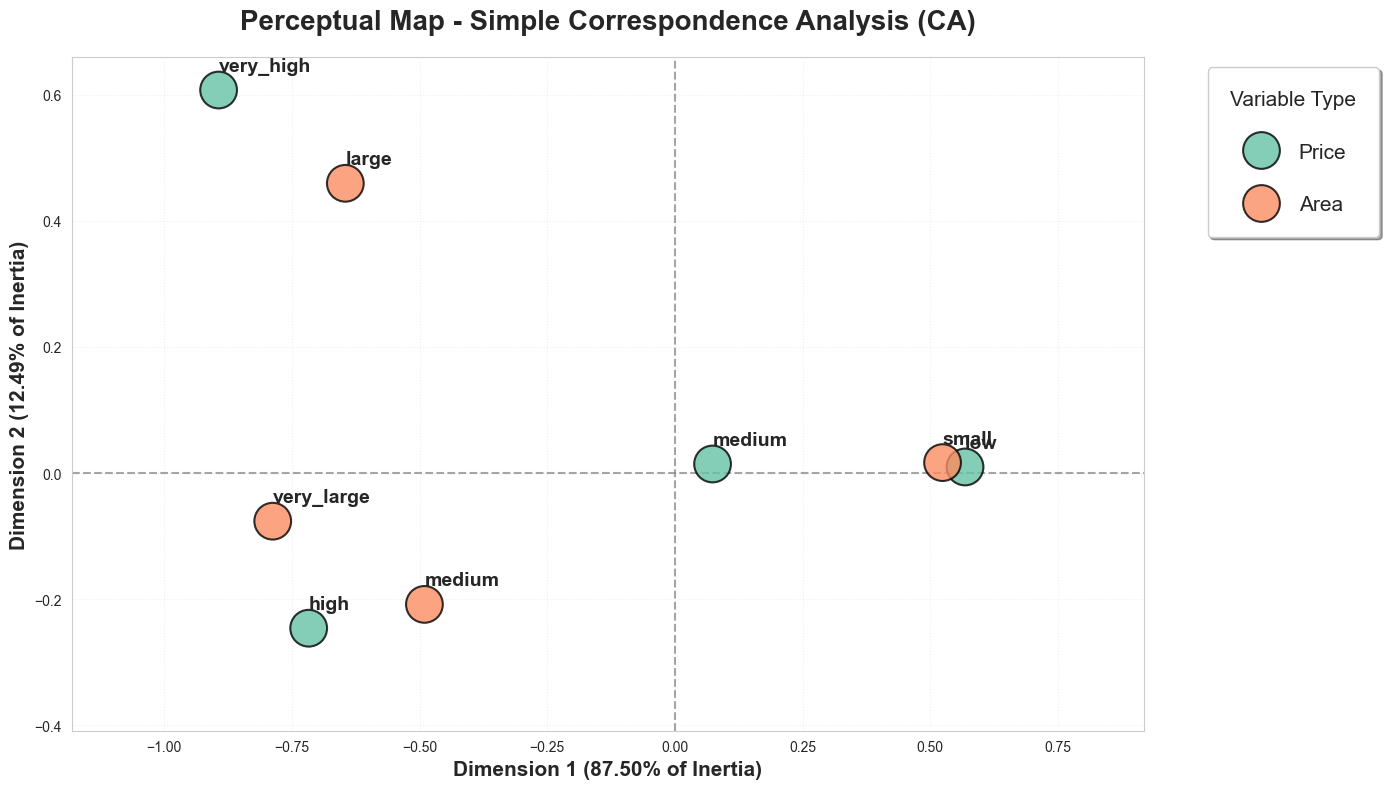

INERTIA RESUME (Dimensional Explainability)
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.295        87.50%                     87.50%
1              0.042        12.49%                     99.99%


✓ Both dimensions explain 99.99% of the total variability.

All Eigenvalues:
[0.29475507 0.04208107]

NNumber of dimensions: 2


In [273]:
# Create the contingency table
contingency_table = pd.crosstab(df['price_bin'], df['area_bin'])

print("Contingency Table:")
print(contingency_table)
print("\n")

# Train the Correspondence Analysis model
ca = prince.CA(
    n_components=2,      # Data matrix (min(I-1, J-1))
    n_iter=4,            
    copy=True,           
    check_input=True,    
    engine='sklearn',    
    random_state=42
)
ca = ca.fit(contingency_table)

# Retrieve the coordinates of the categories
row_coords = ca.row_coordinates(contingency_table)  # Row coordinates
col_coords = ca.column_coordinates(contingency_table)  # Collumns coordinates

row_coords.columns = ['Dim 1', 'Dim 2']
col_coords.columns = ['Dim 1', 'Dim 2']

# Add type labels
row_coords['Type'] = 'Price'
row_coords['Category'] = row_coords.index

col_coords['Type'] = 'Area'
col_coords['Category'] = col_coords.index

# Combine both for joint plotting
all_coords = pd.concat([row_coords, col_coords])

# Extract explained inertia
eigenvalues_df = ca.eigenvalues_summary
dim1_variance = eigenvalues_df.iloc[0, 1]
dim2_variance = eigenvalues_df.iloc[1, 1]

if isinstance(dim1_variance, str):
    dim1_variance = float(dim1_variance.replace('%', ''))
    dim2_variance = float(dim2_variance.replace('%', ''))

# Create the biplot
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_style("whitegrid")

# Expanding axis limits
x_min, x_max = col_coords['Dim 1'].min(), col_coords['Dim 1'].max()
y_min, y_max = col_coords['Dim 2'].min(), col_coords['Dim 2'].max()

x_margin = (x_max - x_min) * 0.3
y_margin = (y_max - y_min) * 0.3

ax.set_xlim(x_min - x_margin, x_max + x_margin)
ax.set_ylim(y_min - y_margin, y_max + y_margin)

# Plotting points
plot = sns.scatterplot(
    data=all_coords, 
    x='Dim 1', 
    y='Dim 2', 
    hue='Type', 
    style='Type',
    s=700, 
    palette='Set2',
    markers={'Price': 'o', 'Area': 'o'},
    edgecolor='black',
    linewidth=1.5,
    zorder=3,
    alpha=0.8,
    ax=ax
)

# Adding labels to points
for i in range(all_coords.shape[0]):
    ax.text(
        all_coords['Dim 1'].iloc[i], 
        all_coords['Dim 2'].iloc[i] + 0.03, 
        all_coords['Category'].iloc[i], 
        fontsize=14, 
        weight='bold',
    )

# Adding horizontal and vertical lines at 0
ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axvline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

# Titles and labels
ax.set_title('Perceptual Map - Simple Correspondence Analysis (CA)', 
             fontsize=20, pad=20, weight='bold')
ax.set_xlabel(f'Dimension 1 ({dim1_variance:.2f}% of Inertia)', fontsize=15, weight='bold')
ax.set_ylabel(f'Dimension 2 ({dim2_variance:.2f}% of Inertia)', fontsize=15, weight='bold')

# Legend and grid
ax.legend(title='Variable Type', bbox_to_anchor=(1.05, 1), loc='upper left', 
          fontsize=15, title_fontsize=15, frameon=True, shadow=True,
          labelspacing=1.6, borderpad=1.1)
ax.grid(alpha=0.3, linestyle=':', linewidth=0.8)


plt.tight_layout()
plt.show()

# Show inertia summary
print("="*70)
print("INERTIA RESUME (Dimensional Explainability)")
print("="*70)
print(eigenvalues_df)
print("\n")
print(f"✓ Both dimensions explain {dim1_variance + dim2_variance:.2f}% of the total variability.")
print("="*70)

# Show all eigenvalues
print("\nAll Eigenvalues:")
print(ca.eigenvalues_)
print(f"\nNNumber of dimensions: {len(ca.eigenvalues_)}")

>The Perceptual Map should be interpreted in this way:
>- Categories that are close together indicate a strong positive association.
>- Categories in opposite quadrants suggest a negative association (repulsion).
>
>The analysis reveals a clear, logical progression where "low" price is almost perfectly synonymous with "small" area. In contrast, high" and "very_high" prices are more associated with "large" and "very_large" areas, though "very_high" price stands out as the most distinctive category in the upper-left quadrant. The "medium" categories for both variables sit closer to the origin.
>
>While "high" prices are closely aligned with "very_large" areas, the "very_high" price category (top-left) is actually quite far from the "very_large" area point. This suggests that while the most expensive houses are certainly not "small," their extreme value might be driven by factors other than just maximum square footage, such as premium location, luxury finishes, or specific amenities—rather than just being the biggest houses in the dataset.
>
>When analyzing only two variables (Simple CA), the 2D plot can often capture nearly 100% of the inertia because the relationship is direct and linear. However, as we transition to Multiple Correspondence Analysis (MCA) by adding more features, the complexity of the data increases significantly.

C:\Users\yuhmo\AppData\Local\Temp\ipykernel_127672\3922919510.py:70: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  col_coords['Dim 1'][i],
C:\Users\yuhmo\AppData\Local\Temp\ipykernel_127672\3922919510.py:71: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  col_coords['Dim 2'][i] + 0.15,
C:\Users\yuhmo\AppData\Local\Temp\ipykernel_127672\3922919510.py:72: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  col_coords['Category'][i],


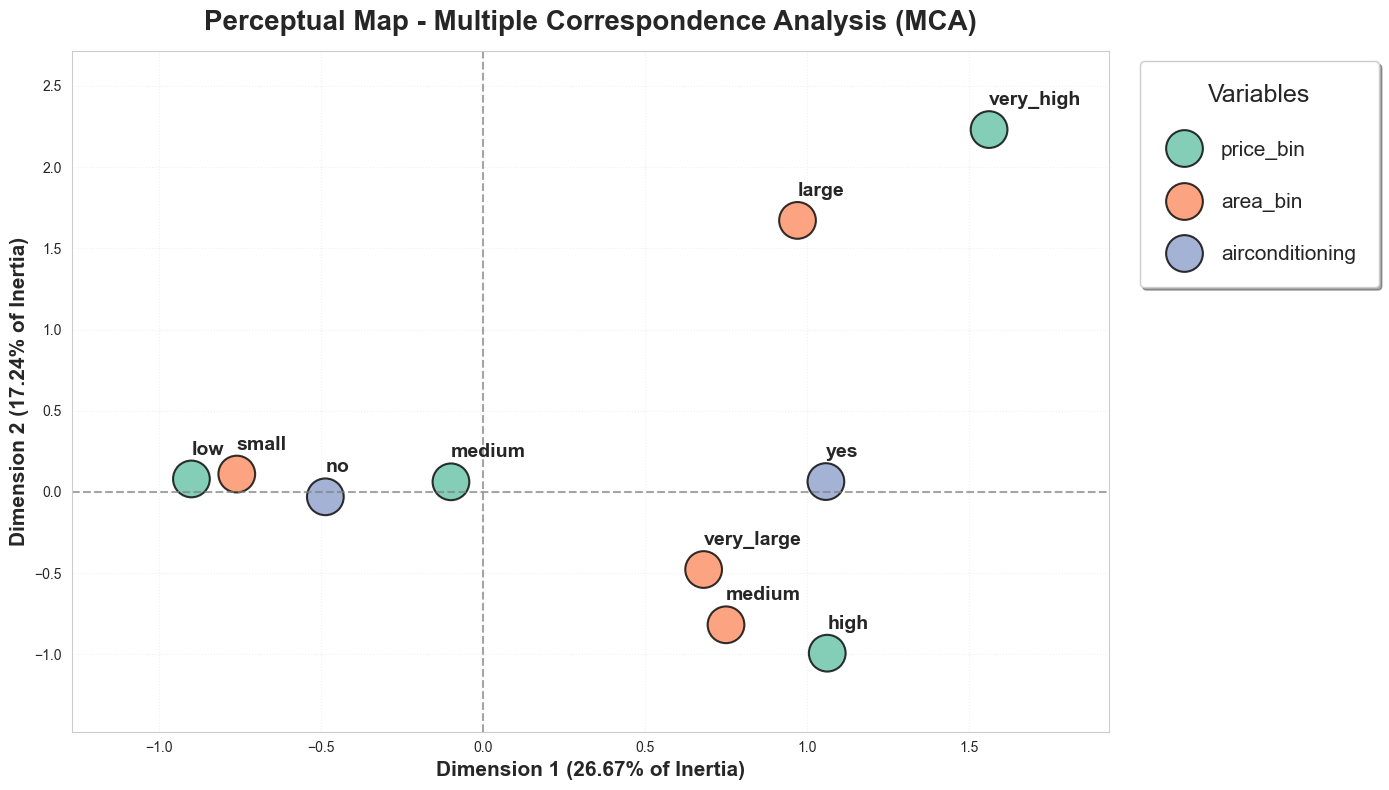

RESUMO DA INÉRCIA (Explicabilidade das Dimensões)
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.622        26.67%                     26.67%
1              0.402        17.24%                     43.90%


✓ As duas primeiras dimensões explicam 43.91% da variabilidade total.


In [274]:
# MCA - Multiple Correspondence Analysis

# Select variables for MCA
cols_to_analyze = ['price_bin', 'area_bin', 'airconditioning']
df_ana = df[cols_to_analyze].copy()

# Initialize and fit the MCA model
mca = prince.MCA(
    n_components=2,      # Number of dimensions to keep
    n_iter=4,            # Iterations for convergence
    copy=True,           # Copy the data
    check_input=True,    # Validate input
    engine='sklearn',    # Engine to use
    random_state=42
)
mca = mca.fit(df_ana)

# Getting the column coordinates
col_coords = mca.column_coordinates(df_ana)
col_coords.columns = ['Dim 1', 'Dim 2']

# Add variable and category labels
col_coords['Variable'] = [col.split('__')[0] for col in col_coords.index]
col_coords['Category'] = [col.split('__')[1] for col in col_coords.index]

# Extract explained inertia
eigenvalues_df = mca.eigenvalues_summary

# Extract variance percentages
dim1_variance = eigenvalues_df.iloc[0, 1]
dim2_variance = eigenvalues_df.iloc[1, 1]

# Convert from string to float if necessary
if isinstance(dim1_variance, str):
    dim1_variance = float(dim1_variance.replace('%', ''))
    dim2_variance = float(dim2_variance.replace('%', ''))

# Create the perceptual map
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_style("whitegrid")

# Expanding axis limits
x_min, x_max = col_coords['Dim 1'].min(), col_coords['Dim 1'].max()
y_min, y_max = col_coords['Dim 2'].min(), col_coords['Dim 2'].max()

x_margin = (x_max - x_min) * 0.15
y_margin = (y_max - y_min) * 0.15

ax.set_xlim(x_min - x_margin, x_max + x_margin)
ax.set_ylim(y_min - y_margin, y_max + y_margin)

# Plotar os pontos
plot = sns.scatterplot(
    data=col_coords, 
    x='Dim 1', 
    y='Dim 2', 
    hue='Variable', 
    s=700, 
    palette='Set2',
    edgecolor='black',
    linewidth=1.5,
    zorder=2,
    alpha=0.8,
    ax=ax
)

# Adding labels to points
for i in range(col_coords.shape[0]):
    ax.text(
        col_coords['Dim 1'][i], 
        col_coords['Dim 2'][i] + 0.15, 
        col_coords['Category'][i], 
        fontsize=14, 
        weight='bold',
    )

# Adding horizontal and vertical lines at 0
ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axvline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

# Titles and labels
ax.set_title('Perceptual Map - Multiple Correspondence Analysis (MCA)', 
             fontsize=20, pad=15, weight='bold')
ax.set_xlabel(f'Dimension 1 ({dim1_variance:.2f}% of Inertia)', fontsize=15, weight='bold')
ax.set_ylabel(f'Dimension 2 ({dim2_variance:.2f}% of Inertia)', fontsize=15, weight='bold')

# Legend and grid
ax.legend(title='Variables', bbox_to_anchor=(1.02, 1), loc='upper left', 
          fontsize=15, title_fontsize=18, frameon=True, shadow=True,
          labelspacing=1.6, borderpad=1.1)
ax.grid(alpha=0.3, linestyle=':', linewidth=0.8)

plt.tight_layout()
plt.show()

# Show inertia summary
print("="*70)
print("RESUMO DA INÉRCIA (Explicabilidade das Dimensões)")
print("="*70)
print(eigenvalues_df)
print("\n")
print(f"✓ As duas primeiras dimensões explicam {dim1_variance + dim2_variance:.2f}% da variabilidade total.")
print("="*70)

>Based on the Multiple Correspondence Analysis (MCA) plot with the addition of the airconditioning feature, we can draw the following conclusions:
>
>>The "yes" category for air conditioning is positioned very close to the "high" price and "very_large" area cluster. This suggests that air conditioning is almost a prerequisite for houses in these categories. Interestingly, the "very_high" price point is pulled further up on Dimension 2, indicating that while these elite houses likely have AC, they are defined by even more extreme or unique characteristics beyond just climate control
>
>>As predicted, the explained inertia dropped significantly (Dimension 1 now captures 26.67% compared to the previous 87.50%). This confirms that adding even one more feature introduces new "noise" or dimensions of information that a 2D plot can no longer fully capture.

In [275]:
mca = prince.MCA(
       n_components=8,   # ou maior, se quiser
       n_iter=4,
       copy=True,
       check_input=True,
       engine='sklearn',
       random_state=42
   ).fit(df_ana)

print(mca.eigenvalues_)
print(mca.eigenvalues_summary)

[6.22221503e-01 4.02208304e-01 3.40970669e-01 3.33275213e-01
 2.69298637e-01 2.24924023e-01 1.40434984e-01 5.49137420e-34]
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.622        26.67%                     26.67%
1              0.402        17.24%                     43.90%
2              0.341        14.61%                     58.52%
3              0.333        14.28%                     72.80%
4              0.269        11.54%                     84.34%
5              0.225         9.64%                     93.98%
6              0.140         6.02%                    100.00%
7              0.000         0.00%                    100.00%


>In the above table we can see how much inertia (variance) is explained by each eigenvalue.

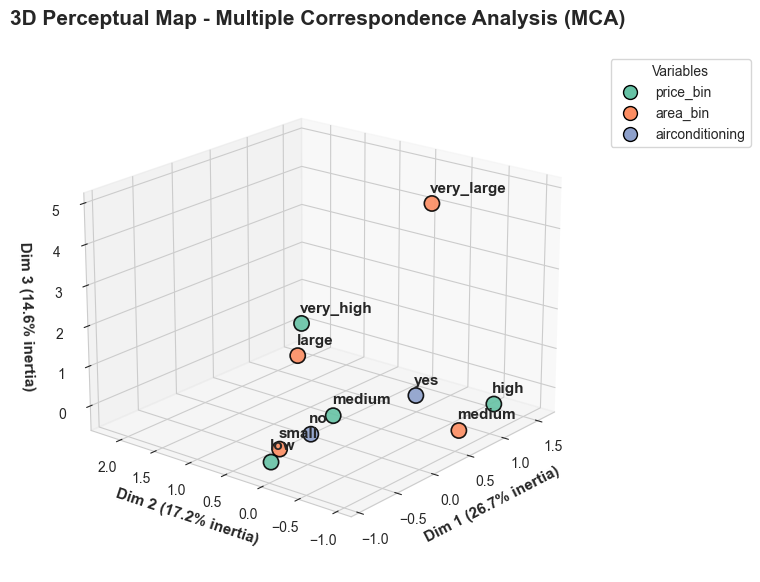

In [276]:
# Refit MCA with 3 components (for 3D)
cols_to_analyze = ['price_bin', 'area_bin', 'airconditioning']
df_ana = df[cols_to_analyze].copy()

mca = prince.MCA(
    n_components=3,      # now 3D
    n_iter=4,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
).fit(df_ana)

# Get coordinates for the first 3 dimensions
col_coords = mca.column_coordinates(df_ana)
col_coords = col_coords.iloc[:, :3]  # keep first 3 dims
col_coords.columns = ['Dim 1', 'Dim 2', 'Dim 3']

col_coords['Variable'] = [idx.split('__')[0] for idx in col_coords.index]
col_coords['Category'] = [idx.split('__')[1] for idx in col_coords.index]

# Explained inertia (for labels)
eigenvalues_df = mca.eigenvalues_summary
dim1_var = eigenvalues_df.iloc[0, 1]
dim2_var = eigenvalues_df.iloc[1, 1]
dim3_var = eigenvalues_df.iloc[2, 1]

if isinstance(dim1_var, str):
    dim1_var = float(dim1_var.replace('%', ''))
    dim2_var = float(dim2_var.replace('%', ''))
    dim3_var = float(dim3_var.replace('%', ''))

# Set up 3D figure
sns.set_style("whitegrid")
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Color map by variable
palette = sns.color_palette('Set2', n_colors=col_coords['Variable'].nunique())
var_to_color = {var: palette[i] for i, var in enumerate(col_coords['Variable'].unique())}
colors = col_coords['Variable'].map(var_to_color)

# Scatter plot (static data; we only rotate the view)
sc = ax.scatter(
    col_coords['Dim 1'],
    col_coords['Dim 2'],
    col_coords['Dim 3'],
    c=colors,
    s=120,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.9
)

# Add labels to points
x_range = col_coords['Dim 1'].max() - col_coords['Dim 1'].min()
y_range = col_coords['Dim 2'].max() - col_coords['Dim 2'].min()
z_range = col_coords['Dim 3'].max() - col_coords['Dim 3'].min()

offset_x = x_range * 0.03  # 3% da amplitude
offset_y = y_range * 0.03
offset_z = z_range * 0.02  # 5% para cima

for i, row in col_coords.iterrows():
    ax.text(
        row['Dim 1'] + offset_x,
        row['Dim 2'] + offset_y,
        row['Dim 3'] + offset_z,
        row['Category'],
        fontsize=11,
        weight='bold',
        ha='left',
        va='bottom'
    )

# Axes labels and title
ax.set_title(
    '3D Perceptual Map - Multiple Correspondence Analysis (MCA)',
    fontsize=15, weight='bold', pad=20
)
ax.set_xlabel(f'Dim 1 ({dim1_var:.1f}% inertia)', fontsize=11, weight='bold')
ax.set_ylabel(f'Dim 2 ({dim2_var:.1f}% inertia)', fontsize=11, weight='bold')
ax.set_zlabel(f'Dim 3 ({dim3_var:.1f}% inertia)', fontsize=11, weight='bold')

# Legend
handles = []
for var, color in var_to_color.items():
    h = plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=color, markersize=10,
                   markeredgecolor='black')
    handles.append(h)
ax.legend(handles, var_to_color.keys(), title='Variables', loc='upper left', bbox_to_anchor=(1.05, 1))

# Optional: fix limits for nicer rotation
pad = 0.2
for dim in ['Dim 1', 'Dim 2', 'Dim 3']:
    vmin = col_coords[dim].min()
    vmax = col_coords[dim].max()
    center = (vmin + vmax) / 2
    half_range = (vmax - vmin) / 2 + pad
    if dim == 'Dim 1':
        ax.set_xlim(center - half_range, center + half_range)
    elif dim == 'Dim 2':
        ax.set_ylim(center - half_range, center + half_range)
    else:
        ax.set_zlim(center - half_range, center + half_range)

# Animation function: slowly rotate
def init():
    ax.view_init(elev=20, azim=40)
    return fig,

def animate(frame):
    # frame goes from 0 to n_frames-1
    angle = 40 + frame  # start at 40 degrees
    ax.view_init(elev=20, azim=angle)
    return fig,

n_frames = 180  # ~6s at 30 fps

anim = animation.FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=n_frames,
    interval=50,   # ms between frames (50 ms -> 20 fps)
    blit=False
)

# Save animation
# For GIF (requires ImageMagick or PillowWriter):
from matplotlib.animation import PillowWriter
anim.save('mca_3d_rotation.gif', writer=PillowWriter(fps=20))

ax.set_position([0.2, 0.15, 0.65, 0.65])
plt.show()
plt.close(fig)  # avoid showing static figure in notebook

>Separation of "Very High" Price vs. "Large" Area
>>In 2D, "very_high" price and "large" area appeared to be in the same general direction. The 3D view shows they are actually separated by depth. This confirms that while they are related, "very_high" price houses have specific characteristics (likely captured by Dim 3) that differentiate them from simply being "large" houses, such as extreme luxury or exclusivity.
>
>By adding the third dimension, you are likely capturing an additional 17% of the total variance. This means the distances you see in 3D are a bit more "honest" representation of the true relationships in your data than the 2D simplification.

>The next steps would be run the MCA adding more features and see how the correspondence paterns behave. 